# What the error is made of

Notebook 1 established that a test score moves. This notebook asks *why*, and
the answer turns out to be a clean decomposition into three parts — two you can
trade against each other, and one you are stuck with.

We can do something here that is impossible with real data. Our energy curve is
a **known function**, so we can draw three hundred independent training sets
from it, fit three hundred models, and watch how they differ. Real life gives
you one sample and no way to see the others; this notebook lets you see them.

The three parts:

- **Bias** — how far the *average* model is from the truth. A model too simple
  to follow the pattern is wrong in the same direction every time.
- **Variance** — how far individual models are from their own average. A model
  flexible enough to chase noise gives a different answer on every sample.
- **Irreducible noise** — the measurement error in the target. No model removes
  it, and any method claiming to has fitted the noise.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from methodology_data import (NOISE_SD, TEST_TEMPERATURE, TEST_TRUTH,
                              load_fleet, sample_energy, true_curve)

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50"
INK, SLATE = "#1A1A1A", "#4A5568"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": SLATE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": SLATE, "ytick.color": SLATE,
})


def polynomial(degree):
    return make_pipeline(PolynomialFeatures(degree), LinearRegression())


print(f"irreducible noise: sd {NOISE_SD} kWh, so a variance of "
      f"{NOISE_SD ** 2:.0f} that no model can ever remove")

irreducible noise: sd 22.0 kWh, so a variance of 484 that no model can ever remove


## 1. Three hundred parallel universes

Each faint line below is a model fitted to a *different* training sample of 25
observations from the same curve. In real life you would have drawn exactly one
of them and never known about the rest.

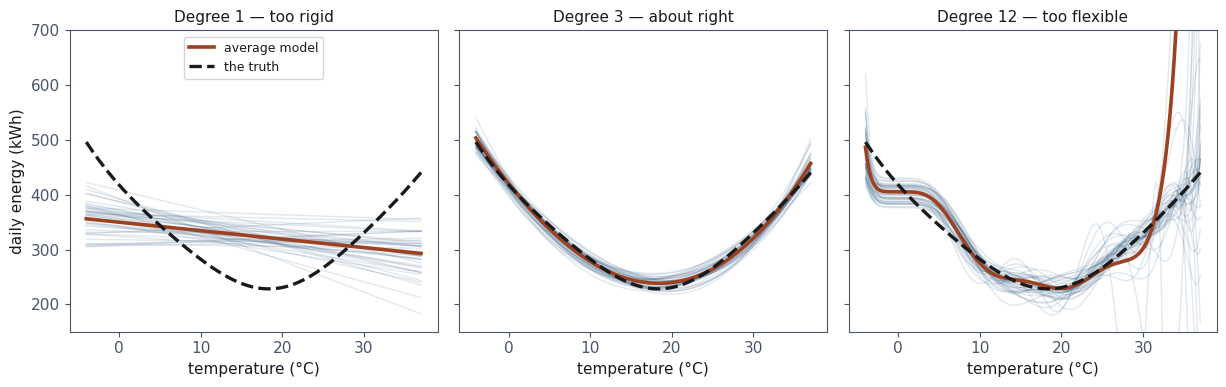

In [2]:
def fit_many(degree, n_train=25, n_samples=300, seed=0):
    """Fit the same model to many independent training sets."""
    rng = np.random.default_rng(seed)
    predictions = []
    for _ in range(n_samples):
        temperature, energy = sample_energy(n_train, rng)
        model = polynomial(degree).fit(temperature.reshape(-1, 1), energy)
        predictions.append(model.predict(TEST_TEMPERATURE.reshape(-1, 1)))
    return np.array(predictions)


fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.0), sharey=True)
for ax, degree, title in ((axes[0], 1, "Degree 1 — too rigid"),
                          (axes[1], 3, "Degree 3 — about right"),
                          (axes[2], 12, "Degree 12 — too flexible")):
    predictions = fit_many(degree)
    for row in predictions[:40]:
        ax.plot(TEST_TEMPERATURE, row, color=BLUE, alpha=.13, lw=1)
    ax.plot(TEST_TEMPERATURE, predictions.mean(axis=0), color=RUST, lw=2.6,
            label="average model")
    ax.plot(TEST_TEMPERATURE, TEST_TRUTH, color=INK, lw=2.4, ls="--",
            label="the truth")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("temperature (°C)")

axes[0].set_ylabel("daily energy (kWh)")
axes[0].set_ylim(150, 700)
axes[0].legend(loc="upper center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "many_universes.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Read the three panels as three different failures.

**Degree 1.** The forty lines lie almost on top of each other — the model is
stable, it barely notices which sample it got. And the red average is nowhere
near the black truth. **That gap is bias**: being confidently, consistently
wrong.

**Degree 3.** The average tracks the truth closely and the spread is modest.
Both quantities are small, which is what "about right" means.

**Degree 12.** Through the middle it follows the truth better than degree 1 ever
could. At the edges the individual lines fly off in every direction, and the red
average is dragged off the top of the plot with them. **That scatter is
variance**, and any single one of those lines is a model somebody actually
deployed.

Two things worth saying about the third panel, because the second one surprises
people.

The scatter is worst **where the data runs out**. Between about 5 °C and 30 °C
the fits agree; beyond that they have nothing to constrain them and a
twelfth-degree polynomial will do anything it likes. Extrapolation is where
flexible models embarrass themselves.

And degree 12 turns out to have **worse bias than degree 1**, which sounds
impossible for a more flexible model. It is an artefact of what "average" means
here: averaging a bundle of wildly unstable curves does not produce a sensible
curve. When variance is this large it contaminates the bias term too, so read
the two numbers together rather than separately.

## 2. Measuring the three parts

The decomposition says that for a fixed test point, the expected squared error
of a model fitted to a random training set is

$$\mathbb{E}\left[(\hat{y} - y)^2\right] =
  \underbrace{\left(\mathbb{E}[\hat{y}] - f\right)^2}_{\text{bias}^2}
  + \underbrace{\mathbb{E}\left[(\hat{y} - \mathbb{E}[\hat{y}])^2\right]}_{\text{variance}}
  + \underbrace{\sigma^2}_{\text{noise}}$$

The handout derives it. Here we simply check that it is true, which is more
convincing than a derivation for most people — and it is only possible because
we know $f$ and $\sigma$.

In [3]:
def decompose(degree, n_train=25, n_samples=300, seed=0):
    predictions = fit_many(degree, n_train, n_samples, seed)
    mean_prediction = predictions.mean(axis=0)
    bias_squared = np.mean((mean_prediction - TEST_TRUTH) ** 2)
    variance = float(np.mean(predictions.var(axis=0)))
    noise = NOISE_SD ** 2
    expected_mse = np.mean((predictions - TEST_TRUTH) ** 2) + noise
    return bias_squared, variance, noise, expected_mse


DEGREES = [1, 2, 3, 5, 9, 12]
rows = []
for degree in DEGREES:
    bias_squared, variance, noise, expected_mse = decompose(degree)
    rows.append({
        "degree": degree, "bias²": bias_squared, "variance": variance,
        "noise": noise, "sum": bias_squared + variance + noise,
        "measured MSE": expected_mse,
    })

table = pd.DataFrame(rows).set_index("degree")
print(table.to_string(float_format=lambda v: f"{v:12,.1f}"))
print(f"\nlargest disagreement between the sum and the measurement: "
      f"{(table['sum'] - table['measured MSE']).abs().max():.2e}")

              bias²     variance        noise          sum  measured MSE
degree                                                                  
1           5,250.8        723.8        484.0      6,458.6       6,458.6
2              59.6         70.8        484.0        614.3         614.3
3              44.5        125.8        484.0        654.4         654.4
5               8.9        368.9        484.0        861.8         861.8
9              80.1     65,186.0        484.0     65,750.1      65,750.1
12        153,537.3 32,174,344.9        484.0 32,328,366.2  32,328,366.2

largest disagreement between the sum and the measurement: 2.73e-12


**The last two columns are identical.** Not approximately — to the limits of
floating point. The decomposition is not a metaphor or a rough guide; it is an
algebraic identity, and we have just watched it hold.

Now read down the table.

**Degree 1 is a bias problem.** Its bias² dwarfs everything else, and its
variance is the smallest in the table. It is stable and wrong.

**Degree 12 is a variance problem.** Look at the magnitude — 32 million, larger
than everything else in the table combined by four orders of magnitude. On 25
observations a degree-12 polynomial is very nearly interpolating, and an
interpolating model is a machine for amplifying noise. Its bias² also looks bad,
for the reason given above: with variance this large, the average of the fits is
not a meaningful curve.

**The noise column never moves.** 484, at every complexity. That is the floor:
no model, no algorithm, no amount of data brings the expected error below it.
Any reported error below the noise floor is a sign that the test set has been
contaminated.

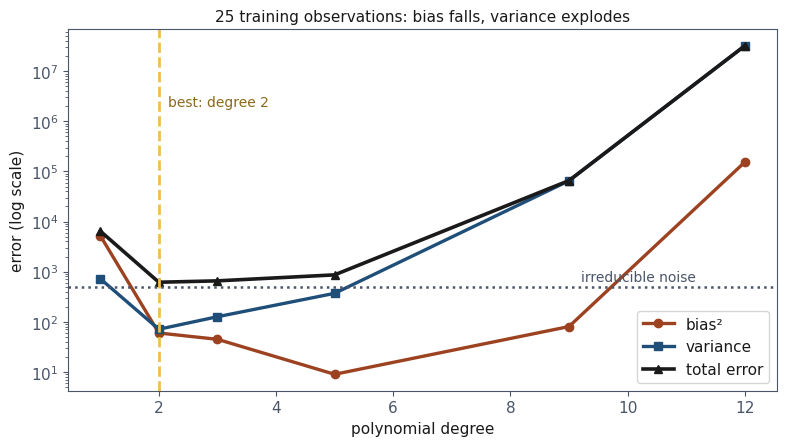

In [4]:
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(DEGREES, table["bias²"], "o-", color=RUST, lw=2.4, label="bias²")
ax.plot(DEGREES, table["variance"], "s-", color=BLUE, lw=2.4, label="variance")
ax.plot(DEGREES, table["measured MSE"], "^-", color=INK, lw=2.6,
        label="total error")
ax.axhline(NOISE_SD ** 2, color=SLATE, ls=":", lw=1.8)
ax.text(9.2, NOISE_SD ** 2 * 1.35, "irreducible noise", color=SLATE, fontsize=10)

best = int(table["measured MSE"].idxmin())
ax.axvline(best, color=GOLD, ls="--", lw=2)
ax.text(best + 0.15, 2e6, f"best: degree {best}", color="#8a6a1a", fontsize=10)

ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("error (log scale)")
ax.set_title("25 training observations: bias falls, variance explodes",
             fontsize=11)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "bias_variance_tradeoff.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

The classic picture, and the one place where the classic picture is usually
drawn without anyone checking it. Bias falls monotonically with complexity;
variance rises; the total is a U whose minimum is the model you want.

The y-axis is logarithmic because otherwise degree 12 would flatten everything
else into the baseline — which is itself worth saying out loud.

## 3. More data moves the answer

The "best degree" above is not a property of the problem. It is a property of
the problem **and how much data you have**. Repeat the whole experiment with 60
observations instead of 25.

In [5]:
comparison = []
for n_train in (25, 60, 150):
    for degree in DEGREES:
        bias_squared, variance, _, expected_mse = decompose(degree, n_train)
        comparison.append({"n": n_train, "degree": degree,
                           "bias²": bias_squared, "variance": variance,
                           "total": expected_mse})

wide = pd.DataFrame(comparison).pivot(index="degree", columns="n",
                                      values="total")
print("total expected error, by training-set size:")
print(wide.to_string(float_format=lambda v: f"{v:14,.1f}"))
print("\nbest degree at each size:")
for n_train in wide.columns:
    print(f"  n = {n_train:>3}: degree {int(wide[n_train].idxmin())}")

total expected error, by training-set size:
n                 25             60             150
degree                                             
1             6,458.6        5,998.6        5,861.5
2               614.3          570.6          555.3
3               654.4          564.6          544.0
5               861.8          540.9          506.9
9            65,750.1          756.6          514.0
12       32,328,366.2        7,626.9          899.0

best degree at each size:
  n =  25: degree 2
  n =  60: degree 5
  n = 150: degree 5


**The optimum moves right as the data grows.** With 25 observations degree 2
wins; by 60 observations degree 5 has taken over, because there is now enough
data to pin down the extra coefficients and its variance has fallen accordingly.
Degree 12 improves by a factor of four thousand between 25 and 150 observations
and is still the worst model in the column.

This is the single most useful practical consequence of the decomposition:

> **"Which model is best?" is not a question about models. It is a question
> about models *and* the amount of data you have.**

It also explains a pattern you will meet constantly — a paper reports that a
large model beat a small one, on a dataset far bigger than yours, and the result
does not reproduce for you. Nothing was wrong with either experiment.

## 4. Learning curves: the diagnostic you can run on real data

Everything above required knowing the truth. Learning curves do not — they are
the practical tool that gets you the same diagnosis from data you actually have.

**The idea.** Train the model on 10% of the data, then 20%, then 40%, and so on,
and plot both the training error and the cross-validated error against the
amount of data used. The *shapes* tell you which problem you have.

Back to the disk fleet, and two deliberately broken models.

**The rigid one** gets a single feature, `power_on_hours` — a real predictor,
but far too little of the story.

**The flexible one** gets all six features plus **150 columns of pure random
noise**, with the penalty turned almost off. That is not a contrived scenario:
it is what a wide feature table looks like when most of the columns carry
nothing, which is most feature tables.

One feature only — high bias
    training 0.715   validation 0.718   gap -0.002
    validation went 0.718 -> 0.718 as the data grew
6 features + 150 noise columns — high variance
    training 1.000   validation 0.847   gap +0.153
    validation went 0.760 -> 0.847 as the data grew


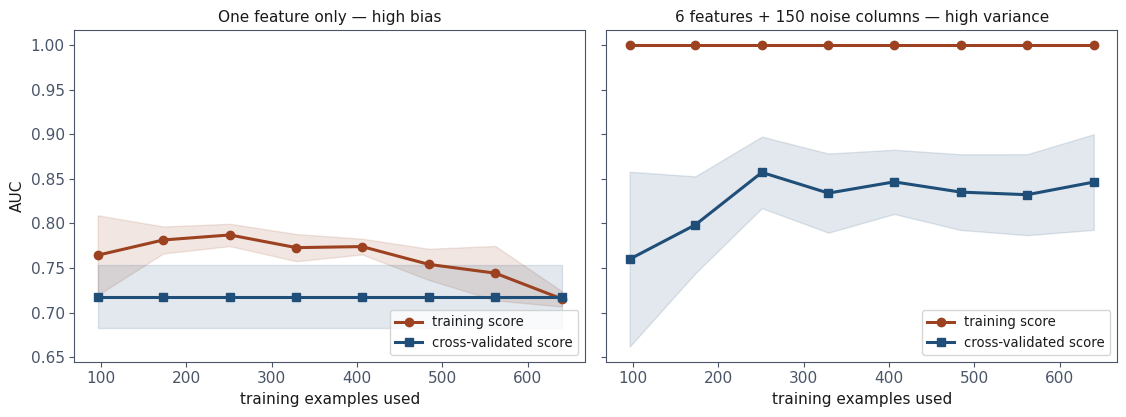

In [6]:
X, y = load_fleet(800)
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
sizes = np.linspace(0.15, 1.0, 8)

rng = np.random.default_rng(0)
noise_columns = pd.DataFrame(
    rng.normal(size=(len(X), 150)),
    columns=[f"noise_{i}" for i in range(150)], index=X.index)
X_wide = pd.concat([X, noise_columns], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3), sharey=True)
for ax, X_use, C, title in (
        (axes[0], X[["power_on_hours"]], 1.0,
         "One feature only — high bias"),
        (axes[1], X_wide, 1000.0,
         "6 features + 150 noise columns — high variance")):
    model = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=5_000, C=C))
    counts, train_scores, valid_scores = learning_curve(
        model, X_use, y, train_sizes=sizes, cv=folds, scoring="roc_auc")

    ax.plot(counts, train_scores.mean(axis=1), "o-", color=RUST, lw=2.2,
            label="training score")
    ax.fill_between(counts, train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    color=RUST, alpha=.13)
    ax.plot(counts, valid_scores.mean(axis=1), "s-", color=BLUE, lw=2.2,
            label="cross-validated score")
    ax.fill_between(counts, valid_scores.mean(axis=1) - valid_scores.std(axis=1),
                    valid_scores.mean(axis=1) + valid_scores.std(axis=1),
                    color=BLUE, alpha=.13)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("training examples used")
    ax.legend(loc="lower right", fontsize=9.5)

    train_mean, valid_mean = train_scores.mean(axis=1), valid_scores.mean(axis=1)
    print(f"{title}")
    print(f"    training {train_mean[-1]:.3f}   validation {valid_mean[-1]:.3f}"
          f"   gap {train_mean[-1] - valid_mean[-1]:+.3f}")
    print(f"    validation went {valid_mean[0]:.3f} -> {valid_mean[-1]:.3f} "
          f"as the data grew")

axes[0].set_ylabel("AUC")
fig.tight_layout()
fig.savefig(FIGURES / "learning_curves.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

## 5. How to read a learning curve

Two shapes, two prescriptions, and getting them the wrong way round wastes
weeks.

**High bias — the left panel.** The two curves meet, and they meet *low*: 0.715
against 0.718, a gap of essentially nothing, and the validation curve is flat
from the first point to the last. The model is equally mediocre on data it has
seen and data it has not, because it has extracted everything one column
contains and one column is not enough.

*What helps:* a more flexible model, better features, less regularisation.
*What does not:* **more data.** The curve is already flat — more rows land on the
same plateau. This is the expensive mistake, because collecting data is the
slowest and costliest thing on the list, and the shape of this plot says in
advance that it will buy nothing.

**High variance — the right panel.** Training **1.000** against validation
0.847: a gap of 0.15, and the validation curve is still climbing at the
right-hand edge, having risen from 0.760. A training score of exactly 1.000
means the model has separated its training set perfectly — through 150 columns
that contain nothing.

*What helps:* more data — and here the rising curve says so explicitly, since it
has not levelled off. Also stronger regularisation, fewer features, a simpler
model.

**The one-line diagnostic:** *is the gap large, and is the validation curve still
rising?* If yes, get more data. If the curves have met and settled, more data is
money spent on nothing.

## What to take away

- Expected error decomposes **exactly** into bias² + variance + noise. We
  measured all three and the identity held to floating-point precision.
- **Bias is being consistently wrong; variance is being unreliably right.** The
  three-panel picture is the one to remember.
- **The noise floor never moves.** A reported error below it means the test set
  has been contaminated, not that the model is exceptional.
- **The best model depends on how much data you have.** The optimal polynomial
  degree moved as the training set grew.
- **Learning curves give you the same diagnosis without knowing the truth.**
  Curves that meet low mean bias — more data will not help. A wide gap with a
  rising validation curve means variance — more data will.

Notebook 3 turns to the ways this whole apparatus can still be defeated: leakage
that survives cross-validation, and hyperparameter searches that quietly consume
their own validation set.